In [4]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
from statsmodels.tsa.arima.model import ARIMA

In [6]:
import os
os.getcwd()

'/Users/shardul/Inverse_problems_in_QM/notebooks/agnr/time_series'

In [8]:
pristine_9 = np.load("../../../9_agnr_pris.csv.npy")
pristine_7 = np.load("../../../7_agnr_pris.csv.npy")

In [9]:
X_7 = np.load(os.path.expanduser("~/transmission_data/consolidated_data/size_7.npy"))
X_9 = np.load(os.path.expanduser("~/transmission_data/consolidated_data/size_9.npy"))

In [10]:
concs = np.arange(2, 60, 2)
indices = concs // 2 - 1


X_7_train = np.clip(X_7[indices, :10000,:150],0,3).reshape(-1,150)
X_9_train = np.clip(X_9[indices, :10000,:150],0,4).reshape(-1,150)
Y_7_predict = np.clip(X_7[indices, :10000,150:170],0,3).reshape(-1,20)
Y_9_predict = np.clip(X_9[indices, :10000,150:170],0,4).reshape(-1,20)


In [11]:
Y_9_predict

array([[3.55233789, 3.78265048, 3.39703506, ..., 2.88465107, 2.83247657,
        2.78488037],
       [3.77517094, 3.81205701, 3.75043714, ..., 2.83861415, 2.890265  ,
        2.88496159],
       [3.59223458, 3.64456409, 3.74326379, ..., 2.8276468 , 2.84490564,
        2.86136054],
       ...,
       [0.93684357, 0.54091121, 1.1068353 , ..., 1.24746912, 0.90711578,
        0.80832842],
       [0.56048525, 1.77058508, 0.89685518, ..., 0.01867136, 0.75283792,
        0.15572436],
       [0.33543806, 0.87461507, 1.62638023, ..., 0.86692251, 0.56562032,
        0.28221245]], shape=(290000, 20))

In [12]:
X_train = np.vstack([X_7_train,X_9_train])
Y_train = np.vstack([Y_7_predict,Y_9_predict])

In [13]:
df_X = pd.DataFrame(X_train,columns=[f"signal_{i}" for i in range(150)])
df_Y = pd.DataFrame(Y_train,columns=[f"signal_{i}" for i in range(20)])

In [14]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

In [15]:
random_sample = df_X.sample(frac=0.8,random_state=42).index
test_sample = df_X.index.difference(random_sample)

In [16]:
train = df_X.loc[random_sample]
target = df_Y.loc[random_sample]
test_input = df_X.loc[test_sample]
target_input = df_Y.loc[test_sample]

In [29]:
import lightgbm as lgbm
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import root_mean_squared_error

In [46]:
models = {}
predictions = {}
per_signal_rmse = {}

callbacks = [
    lgbm.early_stopping(stopping_rounds=30, verbose=False),
    lgbm.log_evaluation(period=0)  # Silence console output during the loop
]

In [36]:
for col in target.columns:
    model = lgbm.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=15,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    
    # Pass train and validation data sliced specifically for the current target column
    model.fit(
        train,
        target[col],
        eval_set=[(test_input, target_input[col])],
        eval_metric="mae",
        callbacks=callbacks
    )
    
    # Store model and generate validation predictions
    models[col] = model
    y_pred = model.predict(test_input)
    predictions[col] = y_pred
    per_signal_rmse[col] = mean_absolute_error(target_input[col], y_pred)

# Assemble predictions into a DataFrame matching target_input shape (N, 20)
df_preds = pd.DataFrame(predictions, index=test_input.index)

# Aggregate validation error
overall_rmse = mean_absolute_error(target_input, df_preds)
print(f"Overall Validation RMSE across all 20 signals: {overall_rmse:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.079272 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 38242
[LightGBM] [Info] Number of data points in the train set: 464000, number of used features: 150
[LightGBM] [Info] Start training from score 0.450149
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.096727 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 38242
[LightGBM] [Info] Number of data points in the train set: 464000, number of used features: 150
[LightGBM] [Info] Start training from score 0.442392
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.049425 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 38242
[LightGBM] [Info] Number of data points in the train set: 464000, number of used features: 150
[LightGBM] [Info] 

In [32]:
best_iters = {col: model.best_iteration_ for col, model in models.items()}
print("Best iteration per signal:", best_iters)

Best iteration per signal: {'signal_0': 1000, 'signal_1': 1000, 'signal_2': 1000, 'signal_3': 1000, 'signal_4': 1000, 'signal_5': 1000, 'signal_6': 1000, 'signal_7': 1000, 'signal_8': 1000, 'signal_9': 1000, 'signal_10': 1000, 'signal_11': 1000, 'signal_12': 1000, 'signal_13': 1000, 'signal_14': 1000, 'signal_15': 1000, 'signal_16': 1000, 'signal_17': 1000, 'signal_18': 1000, 'signal_19': 1000}


In [33]:
# Top 5 most important input features for signal_0
feat_imp = pd.Series(models["signal_0"].feature_importances_, index=train.columns)
print(feat_imp.nlargest(5))

signal_149    493
signal_96     309
signal_148    297
signal_99     292
signal_24     290
dtype: int32


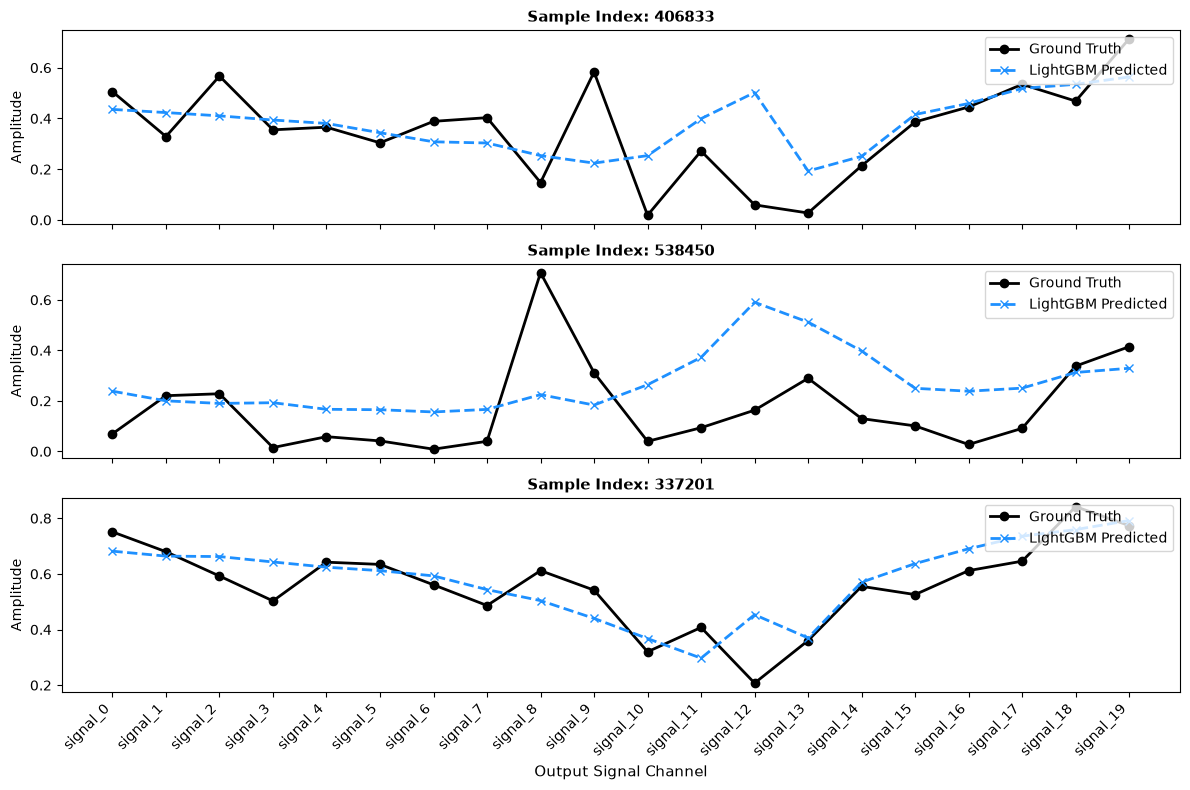

In [37]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
sample_indices = target_input.sample(3, random_state=42).index

for i, idx in enumerate(sample_indices):
    axes[i].plot(
        target_input.columns,
        target_input.loc[idx].values,
        label="Ground Truth",
        marker="o",
        color="black",
        linewidth=2,
    )
    axes[i].plot(
        df_preds.columns,
        df_preds.loc[idx].values,
        label="LightGBM Predicted",
        marker="x",
        linestyle="--",
        color="dodgerblue",
        linewidth=2,
    )
    axes[i].set_title(f"Sample Index: {idx}", fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Amplitude")
    axes[i].legend(loc="upper right")

plt.xticks(rotation=45, ha="right")
plt.xlabel("Output Signal Channel", fontsize=11)
plt.tight_layout()
plt.show()

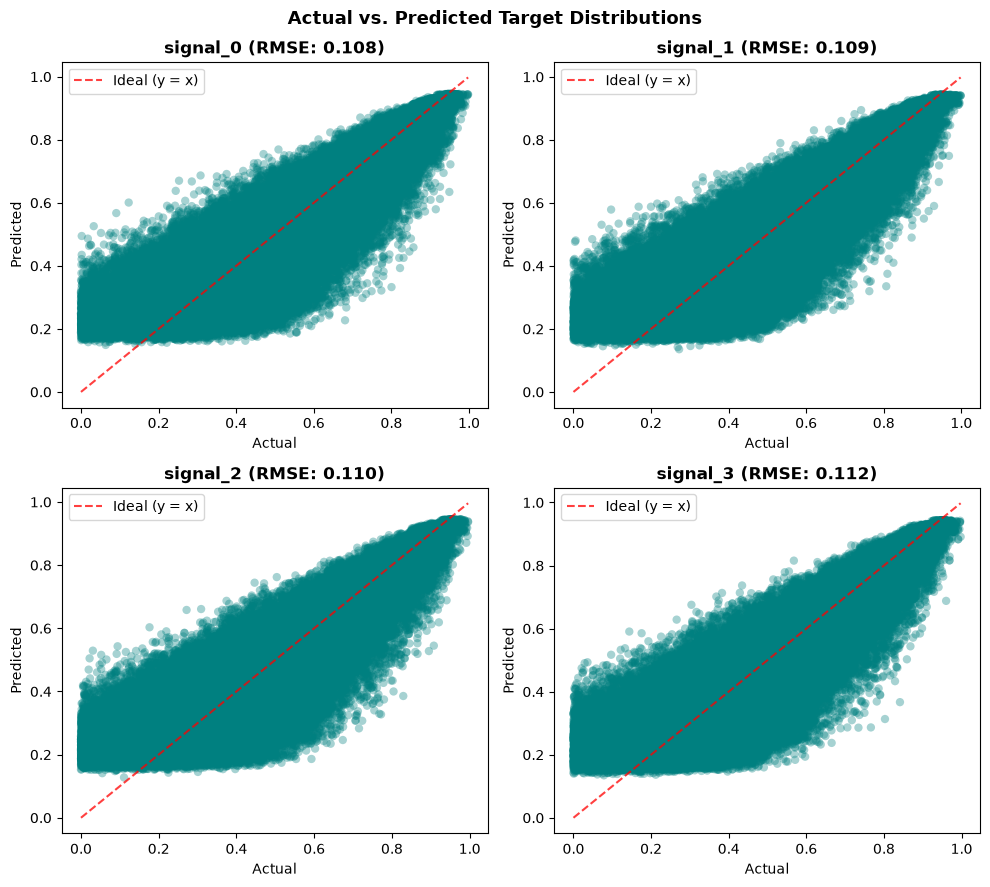

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
sample_cols = target_input.columns[:4]

for ax, col in zip(axes.flatten(), sample_cols):
    y_true = target_input[col]
    y_hat = df_preds[col]

    ax.scatter(y_true, y_hat, alpha=0.35, color="teal", edgecolors="none")

    # 45-degree reference line
    lims = [min(y_true.min(), y_hat.min()), max(y_true.max(), y_hat.max())]
    ax.plot(lims, lims, "r--", alpha=0.75, label="Ideal (y = x)")

    score = root_mean_squared_error(y_true, y_hat)
    ax.set_title(f"{col} (RMSE: {score:.3f})", fontweight="bold")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.legend(loc="upper left")

plt.suptitle(
    "Actual vs. Predicted Target Distributions", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

In [ ]:
import lightgbm as lgb
import numpy as np
import optuna
import pandas as pd
from sklearn.metrics import root_mean_squared_error

# Suppress verbose logs to keep trial output clean
optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    # 1. Define hyperparameter search space
    params = {
        "n_estimators": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1,
    }

    callbacks = [
        lgb.early_stopping(stopping_rounds=30, verbose=False),
        lgb.log_evaluation(period=0),
    ]

    preds = {}
    for col in target.columns:
        model = lgb.LGBMRegressor(**params)
        model.fit(
            train,
            target[col],
            eval_set=[(test_input, target_input[col])],
            eval_metric="rmse",
            callbacks=callbacks,
        )
        preds[col] = model.predict(test_input)

    df_preds = pd.DataFrame(preds, index=test_input.index)
    return root_mean_squared_error(target_input, df_preds)


# 2. Run Bayesian Optimization
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"Best Overall Validation RMSE: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

  0%|          | 0/30 [00:00<?, ?it/s]